# Lecture 9: Introduction to Deep Learning for Image Analysis
**Introduction to Image Analysis — Spring 2026** 

---

The following code uses PyTorch. Install it in your Python environment by running
```bash
pip install scikit-learn torch torchvision
```
from a terminal.

We will also use MedMNIST for the examples. Install the required package with
```bash
pip install medmnist
```

In [1]:
%matplotlib inline

import numpy as np
import torch as th
from torch import nn
from torch.utils.data import DataLoader
from torchvision.transforms.functional import pil_to_tensor
from torchvision.utils import make_grid

import matplotlib.pyplot as plt

## 0. PyTorch quick introduction

PyTorch is a Python library for numerical computing and deep learning.

When you work with data, PyTorch feels very similar to NumPy. The main data structure is a **tensor** (similar to a NumPy array). Many operations use almost the same syntax, so if you know NumPy, learning PyTorch is straightforward.


In [2]:
# NumPy and PyTorch feel very similar for basic array operations
import numpy as np
import torch

a_np = np.array([[1.0, 2.0], [3.0, 4.0]])
a_torch = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

print('NumPy array:\n', a_np)
print('PyTorch tensor:\n', a_torch)

# Shape
print('NumPy shape:', a_np.shape)
print('PyTorch shape:', a_torch.shape)

print('NumPy mean:', a_np.mean())
print('PyTorch mean:', a_torch.mean())

print('NumPy matrix product:\n', a_np @ a_np)
print('PyTorch matrix product:\n', a_torch @ a_torch)


NumPy array:
 [[1. 2.]
 [3. 4.]]
PyTorch tensor:
 tensor([[1., 2.],
        [3., 4.]])
NumPy shape: (2, 2)
PyTorch shape: torch.Size([2, 2])
NumPy mean: 2.5
PyTorch mean: tensor(2.5000)
NumPy matrix product:
 [[ 7. 10.]
 [15. 22.]]
PyTorch matrix product:
 tensor([[ 7., 10.],
        [15., 22.]])


PyTorch has two key features that NumPy does not provide out of the box:

1. **Automatic gradients (autograd):** PyTorch can compute derivatives automatically, which is how neural networks learn during training.
2. **GPU support:** PyTorch can run tensor operations on a GPU, which can make deep learning much faster.


### Automatic gradients

PyTorch can compute derivatives automatically with **autograd**.
If a tensor has `requires_grad=True`, PyTorch tracks operations on it and can compute gradients with `.backward()`.


In [3]:
# Very first autograd example (scalar input)
import torch

x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 2*x

y.backward()

print('x =', x.item())
print('y =', y.item())
print('dy/dx =', x.grad.item())


x = 3.0
y = 15.0
dy/dx = 8.0


Autograd works with input tensors of any shape (scalar, vector, matrix, etc.).
You can combine many tensors to compute a final value.
PyTorch computes gradients of that final value with respect to all inputs that have `requires_grad=True`.
That final value must be a scalar.

For example, we can compute the gradient of $f(\mathbf{w}) = \sum_i \mathbf{w}_i^2$:

In [4]:
# Autograd with a vector: squared norm ||w||^2
import torch

w = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

# Scalar output: sum of squares
loss = (w**2).sum()

# loss is a single number (a scalar, its shape is []):
print("loss.shape =", loss.shape)
loss.backward()

print('w =', w)
print('loss =', loss.item())
print('gradients d(loss)/dw =', w.grad)  # expected: 2*w


loss.shape = torch.Size([])
w = tensor([1., 2., 3.], requires_grad=True)
loss = 14.0
gradients d(loss)/dw = tensor([2., 4., 6.])


### GPU computation

PyTorch can move tensors and models to GPU to speed up computations.
In this lecture, we will keep everything on CPU to keep the code simple.


In [5]:
# Move a tensor to GPU (if available)
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
x = torch.tensor([1.0, 2.0, 3.0]).to(device)

print('Selected device:', device)
print('Tensor:', x)
print('Tensor device:', x.device)

# By default, PyTorch tensors are created on the CPU unless you explicitly set a device

Selected device: cpu
Tensor: tensor([1., 2., 3.])
Tensor device: cpu


Useful PyTorch resources:

- PyTorch tutorials: https://docs.pytorch.org/tutorials/
- Intro to PyTorch: https://docs.pytorch.org/tutorials/beginner/basics/intro.html


## 1. Load image

We start by loading one image that we will use to explore convolution layers and build intuition.


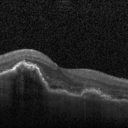

In [6]:
# from medmnist import BreastMNIST
from medmnist import OCTMNIST
# from medmnist import PneumoniaMNIST

image_pil = OCTMNIST(split="train", size=128, download=True)[0][0]
image_pil

We will convert the image to a PyTorch tensor and show shape and data type details.

In [7]:
image = pil_to_tensor(image_pil)
print(f"{image.shape=}")
print(f"{image.dtype=}")

image.shape=torch.Size([1, 128, 128])
image.dtype=torch.uint8


PyTorch stores images as tensors with shape **C × H × W**
(channels, height, width).

The loaded image is `uint8` in the range `[0, 255]`.
Before feeding images to convolution layers, we convert to `float32` and rescale to `[0, 1]`.

In [8]:
image = image.to(dtype=th.float32) / 255.0
print(f"{image.dtype=}")
print(f"{tuple(image.aminmax())=}")

image.dtype=torch.float32
tuple(image.aminmax())=(tensor(0.0118), tensor(0.9529))


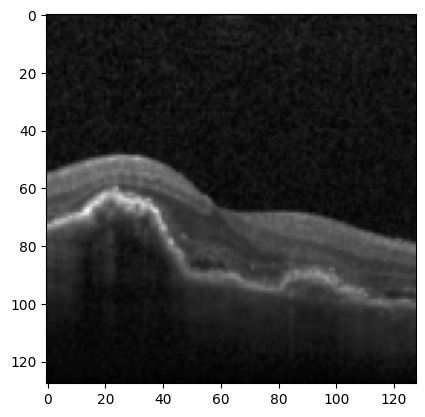

In [9]:
plt.imshow(image[0])

## 2. Convolution layer

Before defining a full CNN, we first explore `nn.Conv2d`,
which is the basic convolution layer in PyTorch.


### 2.1. One channel in, one channel out

We start with the simplest case: one input channel and one output channel.
This means the layer applies one convolution filter to the image.


In [10]:
# Create a convolutional layer
conv1 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=5)

We can inspect the learnable parameters of the layer:

- `weight`: convolution kernel values
- `bias`: one scalar bias per output channel


In [11]:
print(f"{conv1.weight=}")
print(f"{conv1.bias=}")

conv1.weight=Parameter containing:
tensor([[[[ 0.0367, -0.0284,  0.1169, -0.0807,  0.1222],
          [ 0.1442,  0.0829, -0.1635, -0.0364,  0.1829],
          [-0.0705,  0.1299, -0.1089, -0.1932, -0.0716],
          [-0.1350, -0.1870,  0.1363,  0.1331,  0.1710],
          [ 0.0008,  0.0077,  0.1491,  0.0370, -0.1283]]]], requires_grad=True)
conv1.bias=Parameter containing:
tensor([-0.0654], requires_grad=True)


(np.float64(-0.5), np.float64(4.5), np.float64(4.5), np.float64(-0.5))

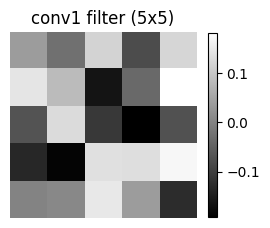

In [12]:
# Visualize conv1.weight (one filter of shape 1x5x5)
plt.figure(figsize=(3, 3))
plt.imshow(conv1.weight[0, 0].detach(), cmap='gray')
plt.title("conv1 filter (5x5)")
plt.colorbar(shrink=0.8)
plt.axis("off")


Note that `weight` and `bias` are initialized **randomly**. Initializing parameters in neural networks is not completely trivial, but PyTorch's initialization usually works well in practice without further tuning.

We can now apply the convolution and visualize the result:

Text(0.5, 1.0, 'Output of convolution layer')

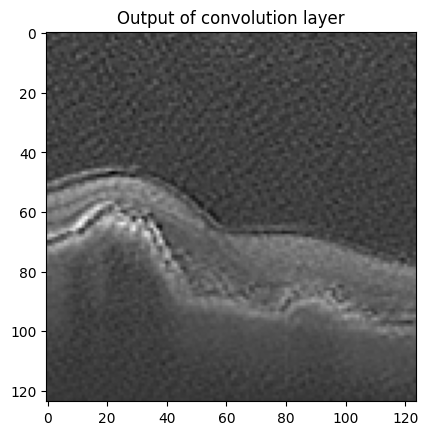

In [13]:
# Apply the convolutional layer to the test image
out = conv1(image)

plt.imshow(out[0].detach())
plt.title("Output of convolution layer")

In [14]:
print(f"{image.shape=}")
print(f"{out.shape=}")

image.shape=torch.Size([1, 128, 128])
out.shape=torch.Size([1, 124, 124])


### 2.2. Padding

The output here is smaller than the input because PyTorch does **not** add padding by default.
In CNNs, we often use padding to preserve spatial size across layers.


In [15]:
# Create a convolution layer with padding=same to keep the image size
conv2 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=5, padding="same")
out = conv2(image)

print("Shapes with padding='same':")
print(f"{image.shape=}")
print(f"{out.shape=}")

Shapes with padding='same':
image.shape=torch.Size([1, 128, 128])
out.shape=torch.Size([1, 128, 128])


## 2.3. Multiple convolutions in one convolution layer

With one output channel, the layer detects one type of pattern.
Usually we want multiple pattern detectors, so we use multiple output channels.
Each output channel corresponds to one convolution filter.


In [16]:
# Convolution layer with 8 filters (and therefore 8 output channels)
conv3 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding="same")

print(f"{conv3.weight.shape}")
print(f"{conv3.bias.shape}")

torch.Size([8, 1, 5, 5])
torch.Size([8])


In PyTorch, convolution weights have shape:

$$
(\text{out\_channels},\; \text{in\_channels},\; h,\; w)
$$


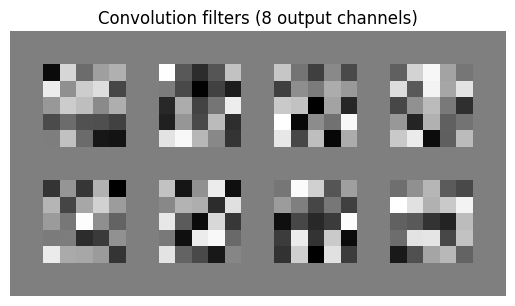

In [17]:
# Visualize the 8 filters

plt.imshow(make_grid(conv3.weight, nrow=4)[0])
plt.axis("off")
plt.title("Convolution filters (8 output channels)");


In [18]:
# Compute the output and visualize the 8 outputs

out3 = conv3(image)
print(f"{image.shape=}")
print(f"{out3.shape=}")

image.shape=torch.Size([1, 128, 128])
out3.shape=torch.Size([8, 128, 128])


Text(0.5, 1.0, 'Output feature maps (8 channels)')

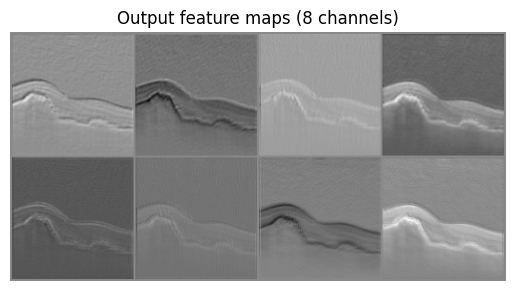

In [19]:
plt.imshow(make_grid(out3[:, None], nrow=4)[0])
plt.axis("off")
plt.title("Output feature maps (8 channels)")


### 2.4. Strided convolution

We can downsample feature maps directly in convolution layers by setting `stride > 1`.
This reduces spatial resolution while increasing receptive field.


In [20]:
conv4 = nn.Conv2d(
    in_channels=1,
    out_channels=8,
    kernel_size=5,
    padding=2,  # We cannot use padding="same" with strided convolutions since the output size will never be the same
    stride=2
)

out4 = conv4(image)
print(f"{image.shape=}")
print(f"{out4.shape=}")

image.shape=torch.Size([1, 128, 128])
out4.shape=torch.Size([8, 64, 64])


## 3. Define the CNN

Now we put the building blocks together into one complete CNN.

In PyTorch, models are defined as subclasses of `nn.Module`.

- In `__init__`, we define layers and hyperparameters.
- In `forward`, we define how data flows through those layers.

We now use this structure to define a small CNN.


In [21]:
class TestCNN(nn.Module):

    def __init__(self):
        # Call parent constructor of nn.Module
        super().__init__()

        # Define our conv layers
        # Note: we could use nn.Sequential for convenience
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding="same")
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3, padding="same")

        self.conv3 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1, stride=2)
        self.conv4 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding="same")

        self.conv5 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1, stride=2)
        self.conv6 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding="same")

        # Define our activation layer
        self.relu = nn.ReLU()

        # Global avg pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # FC layer
        self.fc = nn.Linear(in_features=32, out_features=2)

        # Softmax
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        """
        Defines the interaction between layers
        """
        # x is the input image

        # 1st block
        # x.shape == (1, 128, 128)
        fmap = self.conv1(x)
        fmap = self.relu(fmap)
        # fmap.shape == (8, 128, 128)
        fmap = self.conv2(fmap)
        fmap = self.relu(fmap)
        # fmap.shape == (8, 128, 128)

        # 2nd block
        fmap = self.conv3(fmap)
        fmap = self.relu(fmap)
        # fmap.shape == (16, 64, 64)
        fmap = self.conv4(fmap)
        fmap = self.relu(fmap)
        # fmap.shape == (16, 64, 64)

        # 3rd block
        fmap = self.conv5(fmap)
        fmap = self.relu(fmap)
        # fmap.shape == (32, 32, 32)
        fmap = self.conv6(fmap)
        fmap = self.relu(fmap)
        # fmap.shape == (32, 32, 32)

        # GAP
        fvec = self.gap(fmap)
        fvec = th.squeeze(fvec, dim=(-1, -2))

        # FC
        out = self.fc(fvec)

        # out = self.softmax(out)

        return out


In [22]:
cnn = TestCNN()
out = cnn(image)
print(f"{out.shape=}")

out.shape=torch.Size([2])


In [23]:
th.softmax(out, dim=-1)

tensor([0.5419, 0.4581], grad_fn=<SoftmaxBackward0>)

In [24]:
# Number of parameters
print("Number of parameters:", sum(p.numel() for p in cnn.parameters()))

Number of parameters: 18106


## 4. Data preparation and augmentation

Before training, we define a data augmentation pipeline for training images.
At each mini-batch, it applies random, label-preserving transformations (for example, small flips or rotations), so the model sees different variants of the same cases.
This increases effective data diversity and helps the network generalize better without collecting new data.

In [25]:
from torchvision import transforms

augm_transforms = transform = transforms.Compose([
    # Random flip with prob 0.5
    # transforms.RandomHorizontalFlip(),
    # Random rotation with -10 + 10 degrees
    transforms.RandomRotation(10),
    # Convert PIL to a PyTorch tensor
    transforms.ToTensor(),
])

# We can create much more extreme augmentations
augm_strong_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=(-10, 10),
        translate=(0.05, 0.05),
        scale=(0.9, 1.1),
        # shear=10,
    ),
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
    ),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.RandomAutocontrast(p=0.3),
    transforms.ToTensor(),
])


Now we check the augmentation pipeline and verify that transformed images are tensors in the expected range.


In [26]:
from medmnist import BreastMNIST

# Example of a dataset with data augmentation
augmented_dataset = BreastMNIST(
    split="train",
    size=128,
    download=True,
    transform=augm_strong_transforms  # You can try with augm_strong_transforms
)


In [27]:
pair = augmented_dataset[0]

# The image should be a Tensor instead of PIL
print(f"{type(pair[0])=}")
# Check that dtype is float32
print(f"{pair[0].dtype=}")
# Check that images are in the range [0, 1]
print(f"{pair[0].min()=}, {pair[0].max()=}")

type(pair[0])=<class 'torch.Tensor'>
pair[0].dtype=torch.float32
pair[0].min()=tensor(0.), pair[0].max()=tensor(0.7922)


It is very important that CNN inputs are numerically normalized,
typically to `[0,1]` or around `[-1,1]`.

Feeding raw `[0,255]` values is usually a bad idea because optimization becomes less stable.


Next, we visualize several augmented versions of the __same image__.
Each sample is different because augmentation is random and applied on the fly.


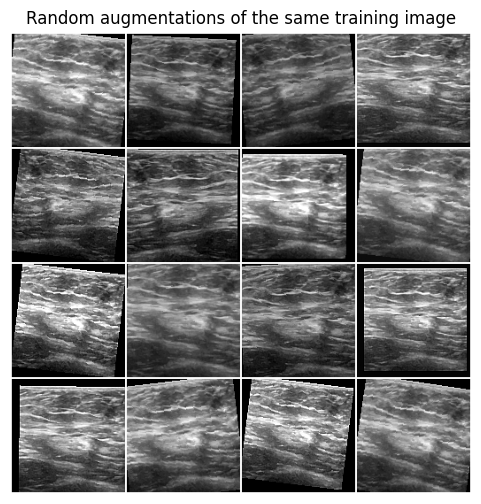

In [28]:
# Get the same image multiple times and plot all of them
images = [augmented_dataset[0][0] for _ in range(16)]

plt.figure(figsize=(6, 6))
grid = make_grid(images, nrow=4, pad_value=1)[0]
plt.imshow(grid)
plt.title("Random augmentations of the same training image")
plt.axis("off");


## 5. Data loading

In this section, we prepare the train/validation datasets and define how data is fed to the network.

First, we create dataset objects with the appropriate preprocessing for each split:
- training split: with augmentation
- validation split: without random augmentation

Then, we wrap these datasets with `DataLoader` objects so PyTorch can iterate in mini-batches efficiently.


In [29]:
BATCH_SIZE = 8
IMAGE_SIZE = 28  # (or 128)

# from medmnist import BreastMNIST
# from medmnist import OCTMNIST
from medmnist import PneumoniaMNIST

# Training data: with data augmentation
data_train = PneumoniaMNIST(
    split="train",
    size=IMAGE_SIZE,
    download=True,
    transform=augm_transforms,
    target_transform=lambda label: label.item()
)

# Validation data: tensor conversion only (no random augmentation)
data_val = PneumoniaMNIST(
    split="val",
    size=IMAGE_SIZE,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=lambda label: label.item()
)

In [30]:
print(f"{len(data_train)} samples in training dataset")
print(f"{len(data_val)} samples in validation dataset")

4708 samples in training dataset
524 samples in validation dataset


Each dataset item is a pair `(image, label)`.
After applying transforms, images are tensors and labels indicate the target class.


We now instantiate the `DataLoader` objects for training and validation.

For the training loader, we enable shuffling so each epoch sees the same samples in a different order.
For validation, we keep a fixed order (`shuffle=False`) because no parameter updates are performed there.


In [31]:
loader_train = DataLoader(data_train, batch_size=BATCH_SIZE, shuffle=True)
loader_val = DataLoader(data_val, batch_size=BATCH_SIZE, shuffle=False)

In [32]:
# Example, let's get a first batch
batch_images, batch_labels = next(iter(loader_train))

# The shape of a batch must be (batch_size, num_channels, height, width)
print(f"{batch_images.shape=}")
# The shape of labels must be (batch_size,)
print(f"{batch_labels.shape=}")

batch_images.shape=torch.Size([8, 1, 28, 28])
batch_labels.shape=torch.Size([8])


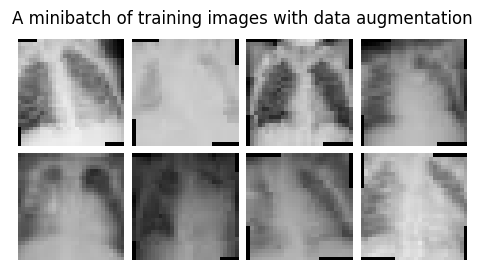

In [33]:
plt.figure(figsize=(6, 6))
grid = make_grid(batch_images, nrow=4, pad_value=1)[0]
plt.imshow(grid)
plt.title("A minibatch of training images with data augmentation")
plt.axis("off");

## 6. Training

Now that we have the model and data loaders, we can train the CNN.
We use cross-entropy loss and optimize model parameters with mini-batch gradient descent.

At each mini-batch, training follows the same four steps:
1. forward pass (compute logits)
2. compute loss
3. backward pass (compute gradients)
4. optimizer step (update parameters)

- Training set: used to update model parameters.
- Validation set: used to monitor performance and choose stopping/checkpoints.


In [34]:
# Create the network to train
cnn = TestCNN()

# We create and Adam optimizer instead of a Stochastic Gradient Descent (SGD) optimizer
# Adam is an extension of SGD with improved training speed and stability.
# The optimizer will automatically update the network's parameters
sgd = th.optim.Adam(cnn.parameters(), lr=1e-4)

In [35]:
# We create the loss function
# Since TestCNN outputs logits, we will use nn.CrossEntropyLoss
loss_function = nn.CrossEntropyLoss()

In [36]:
MAX_EPOCHS = 10   # Maximum number of training epochs
PATIENCE = 5      # Stop if validation loss does not improve for 5 epochs

# History of training and validation losses, for plotting
losses_train = []
losses_val = []

# Parameters for early stopping
best_val_loss = float("inf")  # Best validation loss found so far
bad_epochs = 0                # Number of consecutive epochs where validation loss did not improve
best_epoch = -1               # Epoch with best validation loss so far

# Keep track of the total number of training iterations
n_iterations = 0

for epoch in range(MAX_EPOCHS):
    print(f"Epoch {epoch}...")

    # --- Training phase ---
    cnn.train()  # Set the CNN in training mode
    epoch_train_loss = 0.0
    n_train_batches = 0

    # We run an entire epoch
    for images, labels in loader_train:
        # Compute predictions
        pred_logits = cnn(images)
        # Comput loss averaged over the minibatch
        loss = loss_function(pred_logits, labels)

        sgd.zero_grad()
        # Compute the gradient
        loss.backward()
        # Update parameters
        sgd.step()

        n_iterations += 1

        # Store current loss
        losses_train.append(loss.item())

    # --- Validation phase ---
    cnn.eval()  # Set the CNN in validation mode
    epoch_val_loss = 0.0
    n_val_batches = 0

    with th.no_grad():  # Disable gradient computation (not needed for evaluation)
        for images, labels in loader_val:  # Pass through the validation dataset
            pred_logits = cnn(images)
            val_loss = loss_function(pred_logits, labels)
            epoch_val_loss += val_loss.item()
            n_val_batches += 1

    mean_val_loss = epoch_val_loss / max(n_val_batches, 1)
    losses_val.append((n_iterations - 1, mean_val_loss))

    print(f"  val loss: {mean_val_loss:.4f}")

    # Checkpoint for this epoch
    th.save(cnn.state_dict(), f"checkpoint_{epoch:03d}.pth")

    # Early stopping logic
    if mean_val_loss < best_val_loss:
        best_val_loss = mean_val_loss
        best_epoch = epoch
        bad_epochs = 0
        th.save(cnn.state_dict(), "checkpoint_best.pth")
    else:
        bad_epochs += 1

    if bad_epochs >= PATIENCE:
        print(f"Early stopping at epoch {epoch} (best epoch: {best_epoch})")
        break

print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")


Epoch 0...
  val loss: 0.5605
Epoch 1...
  val loss: 0.5527
Epoch 2...
  val loss: 0.5263
Epoch 3...
  val loss: 0.4265
Epoch 4...
  val loss: 0.4335
Epoch 5...
  val loss: 0.3567
Epoch 6...
  val loss: 0.3469
Epoch 7...
  val loss: 0.3560
Epoch 8...
  val loss: 0.2915
Epoch 9...
  val loss: 0.2801
Best validation loss: 0.2801 at epoch 9


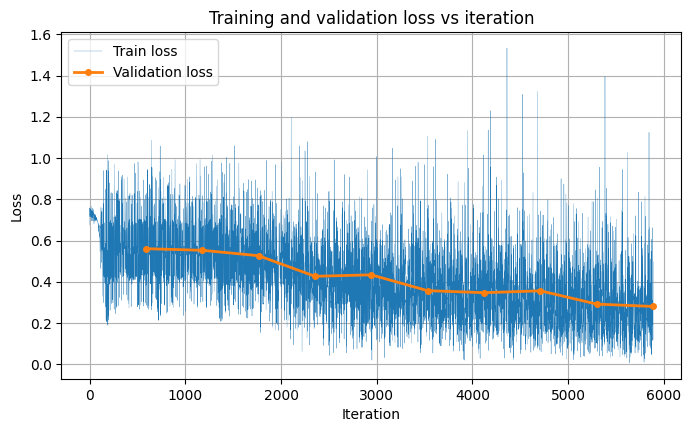

In [37]:
# Plot training and validation loss vs iteration
train_iters = list(range(len(losses_train)))
val_iters = [it for it, _ in losses_val]
val_loss_values = [lv for _, lv in losses_val]

plt.figure(figsize=(8, 4.5))
plt.plot(train_iters, losses_train, label="Train loss", linewidth=0.2)
plt.plot(val_iters, val_loss_values, 'o-', label="Validation loss", linewidth=2, markersize=4)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training and validation loss vs iteration")
plt.grid()
plt.legend();



## 7. Evaluation

After training is finished, we evaluate the model on the test set.
In this section, we compute test accuracy, confusion-matrix-derived metrics, and ROC-AUC.


In [38]:
# Create test dataset and loader (no data augmentation)
data_test = PneumoniaMNIST(
    split="test",
    size=IMAGE_SIZE,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=lambda label: label.item()
)
loader_test = DataLoader(data_test, batch_size=32, shuffle=False)

print(f"{len(data_test)} samples in test dataset")

624 samples in test dataset


We now evaluate the trained model on the test set.

Important: for evaluation we switch the model to `eval()` mode and disable gradient computation with `torch.no_grad()`.
This makes inference correct and more efficient.


In [39]:
from pathlib import Path

# Ensure model is in evaluation mode
cnn.eval()

# Load best checkpoint before final test evaluation (if available)
if Path("checkpoint_best.pth").exists():
    cnn.load_state_dict(th.load("checkpoint_best.pth", map_location="cpu"))

y_true = []
y_pred = []
y_logits = []

with th.no_grad(): # Disable gradient computation (not needed for evaluation)
    for images, labels in loader_test:  # Pass through the test set
        logits = cnn(images)
        # We assume the predicted class is the class with maximum logit
        # In binary classification, this is equivalent to p > 0.5
        preds = th.argmax(logits, dim=1)

        y_logits.append(logits)
        y_pred.append(preds)
        y_true.append(labels.flatten())

# Concatenate all test batches
y_true = th.cat(y_true)
y_pred = th.cat(y_pred)
y_logits = th.cat(y_logits)

accuracy = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {accuracy:.4f}")


Test accuracy: 0.8670


In [40]:
# Confusion matrix entries for binary classification
TP = ((y_pred == 1) & (y_true == 1)).sum().item()
TN = ((y_pred == 0) & (y_true == 0)).sum().item()
FP = ((y_pred == 1) & (y_true == 0)).sum().item()
FN = ((y_pred == 0) & (y_true == 1)).sum().item()

print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")

# Helper to avoid division-by-zero
def safe_div(num, den):
    return num / den if den > 0 else 0.0

sensitivity = safe_div(TP, TP + FN)      # AKA recall, TPR
specificity = safe_div(TN, TN + FP)      # TNR
precision   = safe_div(TP, TP + FP)
f1          = safe_div(2 * precision * sensitivity, precision + sensitivity)

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity:          {specificity:.4f}")
print(f"Precision:            {precision:.4f}")
print(f"F1-score:             {f1:.4f}")


TP=353, TN=188, FP=46, FN=37
Sensitivity (Recall): 0.9051
Specificity:          0.8034
Precision:            0.8847
F1-score:             0.8948


### ROC curve

For binary classification, we can inspect performance across all decision thresholds using the ROC curve.


ROC-AUC: 0.9309


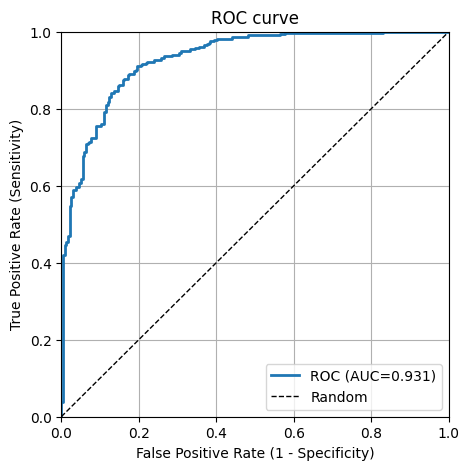

In [41]:
from sklearn.metrics import roc_curve, auc

# Reuse outputs from the single evaluation pass
# For binary classification, use logit/probability of class 1
y_true_np = y_true.cpu().numpy()
y_score_np = y_logits[:, 1].cpu().numpy()

fpr, tpr, thresholds = roc_curve(y_true_np, y_score_np)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5.0, 5.0))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC curve')
plt.grid()
plt.legend(loc='lower right');

print(f"ROC-AUC: {roc_auc:.4f}")

